# Transferring Duffing-trained classifier to cavity fold system

In [1]:

import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = f'{root_dir}/data/regimes/cavity_fold'
model_dir = f'{root_dir}/models/regimes/duffing'
result_dir = f'{root_dir}/results/regimes'

import numpy as np
import torch
import matplotlib.pyplot as plt

import regimes
import util_data
import util_nn


## Learning configuration

In [2]:

# --! specify cavity fold experiment settings
traj_nsample    = 2000                # number of samples in Van der Pol time series trajectories
window_nsample  = 72                  # number of samples in a time series window
future_nsample  = 24                  # number of samples in the future portion of time series window
past_nsample    = 2 * future_nsample  # number of samples in the past portion of time series window
latent_ndim     = 3                   # number of dimensions in future-consistent latent representation
temp_lag        = 5                   # temporal lag tau of slow coordinate s
cov_nsample     = 16                  # number of samples in a covariance window w
cls_nsample     = 16                  # number of samples in classification window r
alpha           = 0.1                 # hyperparameter for slow loss
beta            = 0.01                # hyperparameter for variance loss

# --! set seed to get reproducible behavior
util_nn.set_seed(2026)


## Time series data with cavity fold trajectories

In [3]:

# --! read time series trajectories from a file
data = util_data.read_datafile(f'{data_dir}/trajectories', traj_nsample)
print(f'[note]: shape of read time series is {data.shape}')

ntraj = data.shape[0]
nwindow = traj_nsample - window_nsample
print(f'[note]: number of read time series trajectories is {ntraj}')
print(f'[note]: number of {window_nsample}-sample windows in read trajectories is {nwindow}')

# --! get normalization constants per channel
std_min = torch.tensor(1e-3, dtype=torch.float32)
timeseries_mean = [d.mean() for d in torch.split(data, 1, dim=-1)]
timeseries_std = [torch.maximum(d.std(), std_min) for d in torch.split(data, 1, dim=-1)]

# --! normalize data
data = torch.cat([
    util_data.normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), timeseries_mean, timeseries_std)], dim=-1)

dataset = regimes.encoder_dataset_builder().build(data, past_nsample, future_nsample)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)


[note]: shape of read time series is torch.Size([8, 2000, 2])
[note]: number of read time series trajectories is 8
[note]: number of 72-sample windows in read trajectories is 1928


## Future-consistent latent representation

In [4]:

# --! instantiate past and future encoders
window_ndim = data.shape[-1]
past_enc = regimes.encoder(past_nsample, window_ndim, latent_ndim)
future_enc = regimes.encoder(future_nsample, window_ndim, latent_ndim)

# --! train encoder
regimes.train_encoder(past_enc, future_enc, dataloader, temp_lag=temp_lag, alpha=alpha, beta=beta)

# --! to get access to data in dataset format,
# --! fetch data tuples from data loader and convert them into contiguous tensors
past, future, traj_id, center = zip(*[batch for batch in dataloader])
past = torch.cat(past, dim=0)
traj_id = torch.cat(traj_id, dim=0)

# --! encode past windows
z = past_enc(torch.flatten(past, start_dim=1))

# --! finally, split latent representation according to trajectories
zs = torch.stack(torch.split(z, nwindow, dim=0))
pasts = torch.stack(torch.split(past, nwindow, dim=0))

print(f'inf > shape of z latent space per trajectory is {zs.shape}')
print(f'inf > shape of past windows per trajectory is {pasts.shape}')


[note]: training encoder models for 100 epochs with 0.001 learning rate
	epoch 0, loss: 0.045309
	epoch 20, loss: 0.020351
	epoch 40, loss: 0.023802
	epoch 60, loss: 0.020760
	epoch 80, loss: 0.018748

inf > shape of z latent space per trajectory is torch.Size([8, 1928, 3])
inf > shape of past windows per trajectory is torch.Size([8, 1928, 48, 2])


## Latent dynamical signatures

In [5]:

# --! derive signatures from latent representation
sigs = []
for z in zs:
    z = z.detach().cpu().numpy()
    sig, _ = regimes.make_signatures(z, window_nsample=cov_nsample)
    sigs.append(sig)
sigs = np.stack(sigs)
sigs = torch.as_tensor(sigs, dtype=torch.float32)

print(f'[note]: shape of signatures per trajectory is {sigs.shape}')

# --! if needed, save signatures
datasaved = False
if datasaved:
    util_data.write_datafile(f'{data_dir}/signatures', sigs)
    print(f'[note]: signatures saved')
    util_data.write_datafile(f'{data_dir}/signatures_labels', np.expand_dims(sigs_labels, -1))
    print(f'[note]: labels for signatures saved')

# --! normalize signatures
std_min = torch.tensor(1e-3, dtype=torch.float32)
sigs_mean = [d.mean() for d in torch.split(sigs, 1, dim=-1)]
sigs_std = [torch.maximum(d.std(), std_min) for d in torch.split(sigs, 1, dim=-1)]
sigs = torch.cat([
    util_data.normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(sigs, 1, dim=-1), sigs_mean, sigs_std)], dim=-1)


[note]: shape of signatures per trajectory is torch.Size([8, 1896, 3])


### Displaying latent dynamical signatures

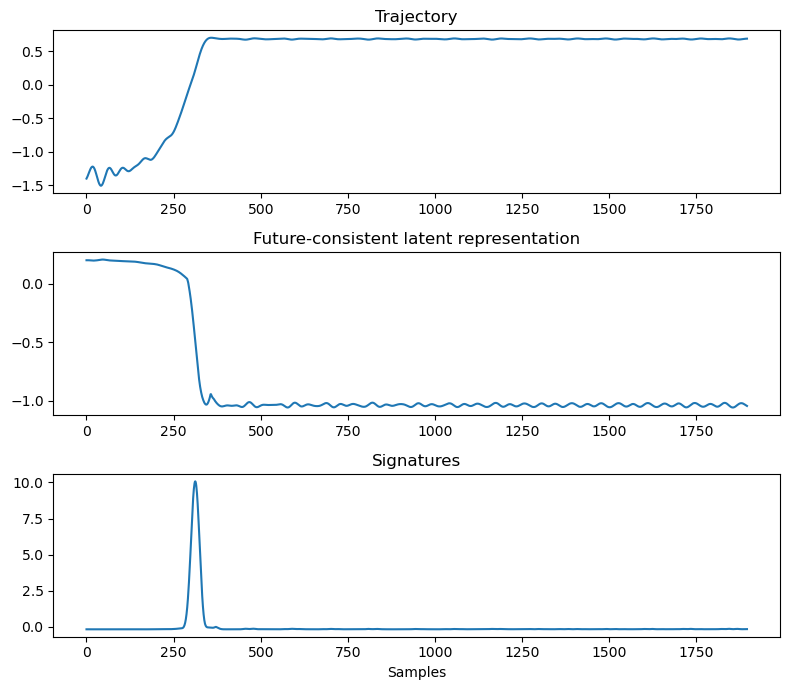

In [6]:

j = 0
x = pasts[j][:, -1, 0]
x = x[cov_nsample:-cov_nsample]
t = np.arange(len(x))

plt.figure(figsize=(8, 7))

plt.subplot(3,1,1)
plt.title('Trajectory')
plt.plot(x)

z = zs[j].detach().cpu().numpy()
c = z[cov_nsample:-cov_nsample, -1]
plt.subplot(3,1,2)
plt.title('Future-consistent latent representation')
plt.plot(c)

d = sigs[j, :, -1]
t = np.arange(len(d))
plt.subplot(3,1,3)
plt.title('Signatures')
plt.plot(d)
plt.xlabel('Samples')

plt.tight_layout()
plt.show()


## Classification of latent dynamical signatures

In [7]:

sig_dataset = regimes.classifier_dataset_builder().build(sigs, cls_nsample)
sig_dataloader = torch.utils.data.DataLoader(sig_dataset, batch_size=512, shuffle=False)

# --! load pre-trained Van der Pol classifier
sig_classifier = regimes.classifier(input_ndim=sigs.shape[-1])
sig_classifier.load_state_dict(torch.load(f'{model_dir}/classifier.pth'))
sig_classifier.eval()

# --! convert tuples into tensors and reshape into trajectories
sigs = [batch for batch in sig_dataloader]
sigs = torch.cat(sigs, dim=0)
sigs = sigs.reshape(ntraj, -1, sigs.shape[-2], sigs.shape[-1])


### Displaying classified signatures

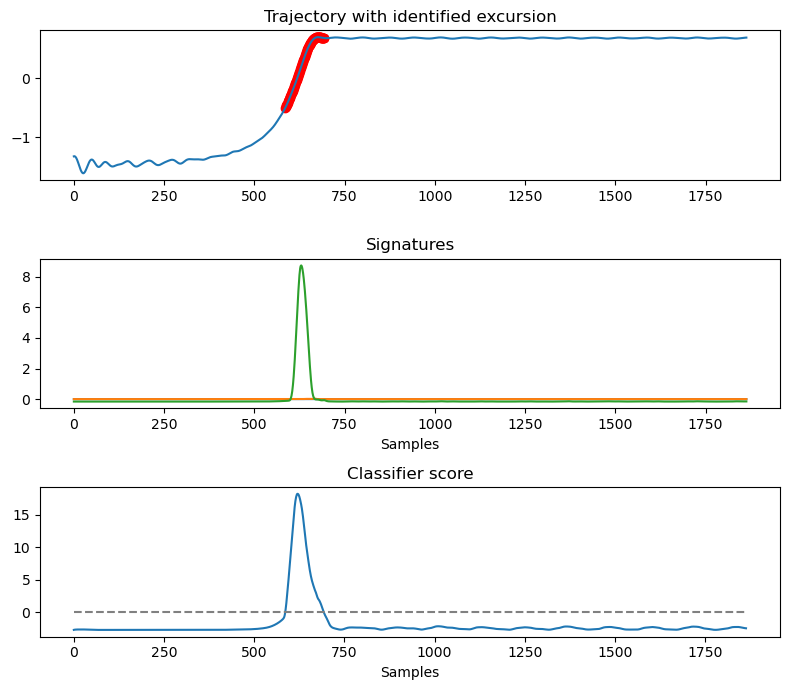

In [8]:

jtraj = 1
window = sigs[jtraj]
logits = []
for w in window:
    o = sig_classifier(torch.transpose(w, -1, -2))
    logits.append(o)
logits = torch.stack(logits)
logits = logits.detach().cpu().numpy()

plt.figure(figsize=(8,7))

x = pasts[jtraj][:, -1, 0]
x = x[cov_nsample:-cov_nsample]
x = x[cls_nsample:-cls_nsample]

t = np.arange(len(x))
i = logits[:, 0] < logits[:, 1]
plt.subplot(3,1,1)
plt.title('Trajectory with identified excursion')
plt.plot(x)
plt.scatter(t[i], x[t[i]], color='red')

x = window[:, cls_nsample - 1]
t = np.arange(len(window))
i_exc = logits[:, 0] < logits[:, 1]

plt.subplot(3,1,2)
plt.title('Signatures')
plt.plot(x)
plt.xlabel('Samples')

plt.subplot(3,1,3)
plt.title('Classifier score')
plt.plot(logits[:, 1] - logits[:, 0])
plt.plot([0, len(logits)],[0, 0], linestyle='dashed', color='gray')
plt.xlabel('Samples')

plt.tight_layout()
plt.show()


### Saving results

In [9]:

datasaved = True
if datasaved:
    traj_i0 = 0
    traj_i1 = 520

    traj = pasts[jtraj][:, -1, 0]
    traj = traj[cov_nsample:-cov_nsample]
    traj = traj[cls_nsample:-cls_nsample]
    traj = traj[traj_i0:traj_i1]

    t = torch.arange(len(traj))
    i_exc = logits[traj_i0:traj_i1, 0] < logits[traj_i0:traj_i1, 1]
    lbls = traj[t[i_exc]]
    i_lbls = t[i_exc]

    lbls = torch.unsqueeze(lbls, 0)
    lbls = torch.unsqueeze(lbls, -1)
    i_lbls = torch.unsqueeze(i_lbls, 0)
    i_lbls = torch.unsqueeze(i_lbls, -1)

    snat = torch.cat([
        util_data.denormalize_standard(
            d, mean, std) for d, mean, std in zip(torch.split(sigs, 1, dim=-1), sigs_mean, sigs_std)], dim=-1)
    snat = snat.reshape(ntraj, -1, snat.shape[-2], snat.shape[-1])
    snat = snat[jtraj]
    snat = snat[traj_i0:traj_i1, cls_nsample - 1]

    score = logits[:, 1] - logits[:, 0]
    score  = score[traj_i0:traj_i1]

    traj  = torch.unsqueeze(traj,  0)
    traj  = torch.unsqueeze(traj, -1)
    snat  = torch.unsqueeze(snat, 0)
    score = np.expand_dims(score, 0)
    score = np.expand_dims(score, -1)

    step = torch.arange(traj.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        step,
        traj, snat, score], axis=2)
    util_data.write_datafile(f'{result_dir}/fold_curves', savedata, delim=' ')

    savedata = np.concatenate([
        i_lbls,
        lbls], axis=2)
    util_data.write_datafile(f'{result_dir}/fold_labels', savedata, delim=' ')

    print(f'[note]: regime discovery saved')


[note]: regime discovery saved
